**Fourier Feature Network using DeepXDE module**

In [48]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


In [49]:
# import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
# from torch.optim.lr_scheduler import ReduceLROnPlateau

Data loading

In [50]:
import os

file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution2.h5"

# Check if the file exists
if not os.path.exists(file_path):
    print("File does not exist.")
else:
    print("File exists.")

# Check the file type
with open(file_path, "rb") as f:
    signature = f.read(8)  # HDF5 files start with this signature
    print("File signature:", signature)
    if signature == b"\x89HDF\r\n\x1a\n":
        print("Valid HDF5 file.")
    else:
        print("Not a valid HDF5 file.")


File exists.
File signature: b''
Not a valid HDF5 file.


In [51]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(np.array(datastore["I"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
t = np.linspace(0, 1, 601).reshape(601, 1)

Train-test split

In [52]:
train_label, test_label = train_test_split(range(len(data_I)), test_size=0.25, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [53]:
X_train = data_i_train.astype(np.float32)
y_train_c = data_c_train.astype(np.float32)

In [54]:
X_test = data_i_test.astype(np.float32)
y_test_c = data_c_test.astype(np.float32)

In [55]:
data_c = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

In [56]:
m = 601
dim_x = 1
net_c = dde.nn.MsFFN(
    [m, 200, 150, 150, m],
    "relu",
    "Glorot normal",
    sigmas = [1, 10]
)

In [57]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [m, 200, 150, 150, m]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 263951


In [58]:
model_c = dde.Model(data_c, net_c)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_c.compile("adam", lr=0.001)
losshistory_c, train_state_c = model_c.train(iterations=1800, display_every=100)

Compiling model...
Building Multiscale Fourier Feature Network...
'compile' took 0.333225 s

Training model...

Step      Train loss    Test loss     Test metric
0         [1.87e+01]    [1.88e+01]    []  
100       [8.63e-01]    [8.87e-01]    []  
200       [3.12e-01]    [3.33e-01]    []  
300       [1.81e-01]    [2.01e-01]    []  
400       [1.29e-01]    [1.50e-01]    []  
500       [1.02e-01]    [1.24e-01]    []  
600       [8.63e-02]    [1.07e-01]    []  
700       [7.49e-02]    [9.61e-02]    []  
800       [6.81e-02]    [8.97e-02]    []  
900       [5.97e-02]    [8.17e-02]    []  
1000      [5.42e-02]    [7.64e-02]    []  
1100      [5.01e-02]    [7.25e-02]    []  
1200      [4.56e-02]    [6.83e-02]    []  
1300      [4.29e-02]    [6.60e-02]    []  
1400      [3.97e-02]    [6.29e-02]    []  
1500      [3.72e-02]    [6.08e-02]    []  
1600      [3.54e-02]    [5.92e-02]    []  
1700      [3.30e-02]    [5.72e-02]    []  
1800      [3.15e-02]    [5.61e-02]    []  

Best model at step 1

In [59]:
y_train_h = data_h_train.astype(np.float32)
y_test_h = data_h_test.astype(np.float32)

In [60]:
data_h = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

In [61]:
m = 601
dim_x = 1
net_h = dde.nn.MsFFN(
    [m, 200, 150, 150, m],
    "relu",
    "Glorot normal",
    sigmas = [1, 10]
)

In [62]:
model_h = dde.Model(data_h, net_h)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h.compile("adam", lr=0.001)
losshistory_h, train_state_h = model_h.train(iterations=1800, display_every=100)

Compiling model...
Building Multiscale Fourier Feature Network...
'compile' took 0.363725 s

Training model...

Step      Train loss    Test loss     Test metric
0         [2.31e-01]    [2.30e-01]    []  
100       [6.73e-03]    [6.89e-03]    []  
200       [3.85e-03]    [4.15e-03]    []  
300       [2.94e-03]    [3.34e-03]    []  
400       [2.55e-03]    [2.99e-03]    []  
500       [2.13e-03]    [2.67e-03]    []  
600       [1.97e-03]    [2.57e-03]    []  
700       [1.77e-03]    [2.46e-03]    []  
800       [1.71e-03]    [2.46e-03]    []  
900       [1.53e-03]    [2.29e-03]    []  
1000      [1.47e-03]    [2.33e-03]    []  
1100      [1.52e-03]    [2.45e-03]    []  
1200      [1.57e-03]    [2.40e-03]    []  
1300      [1.39e-03]    [2.40e-03]    []  
1400      [1.31e-03]    [2.22e-03]    []  
1500      [1.34e-03]    [2.33e-03]    []  
1600      [1.15e-03]    [2.21e-03]    []  
1700      [1.08e-03]    [2.13e-03]    []  
1800      [1.05e-03]    [2.14e-03]    []  

Best model at step 1

13664


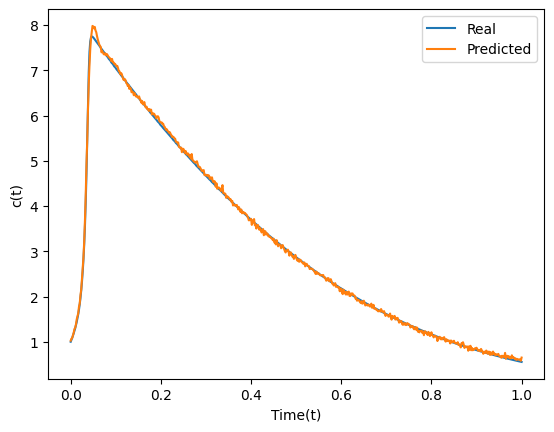

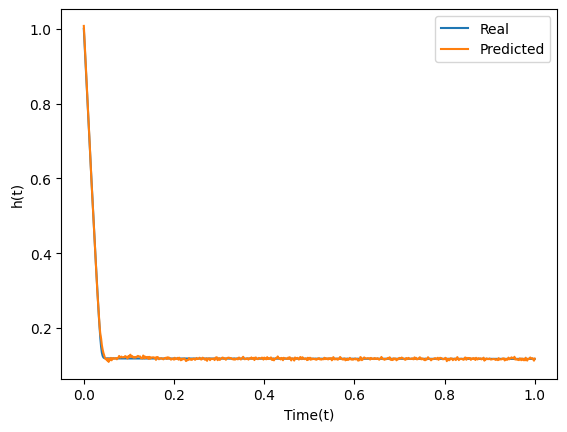

In [63]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

11247


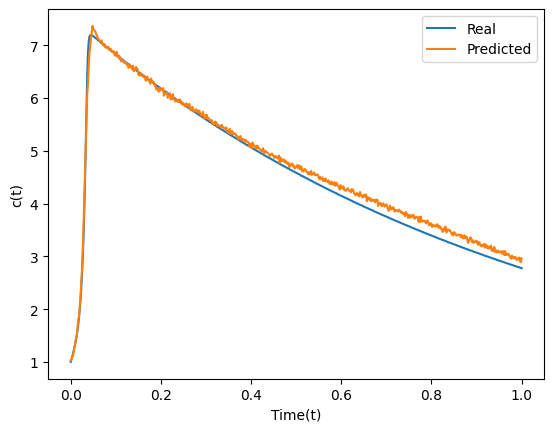

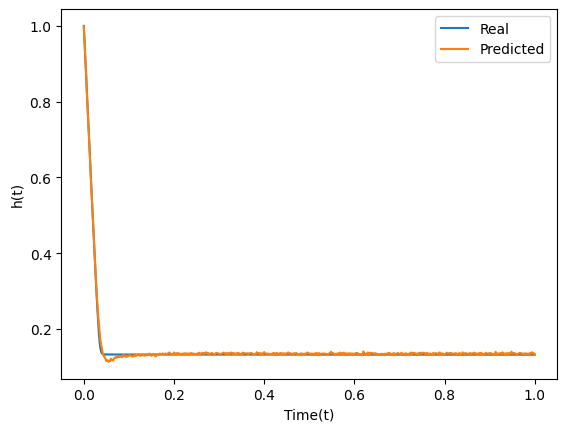

In [64]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

26018


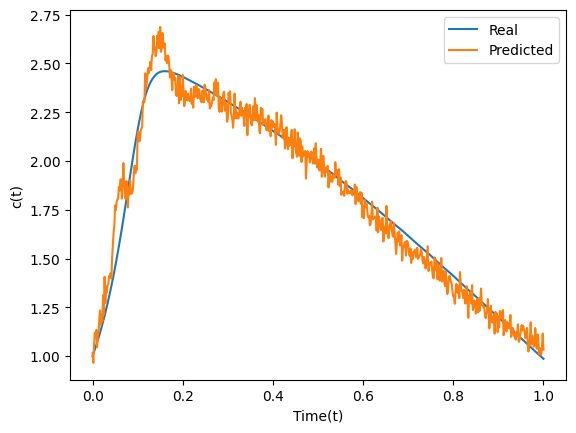

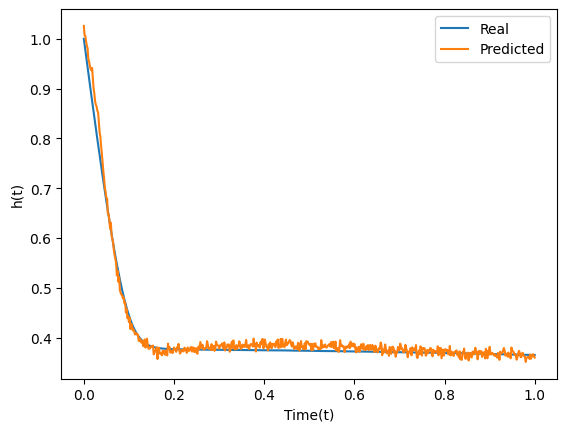

In [65]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

16836


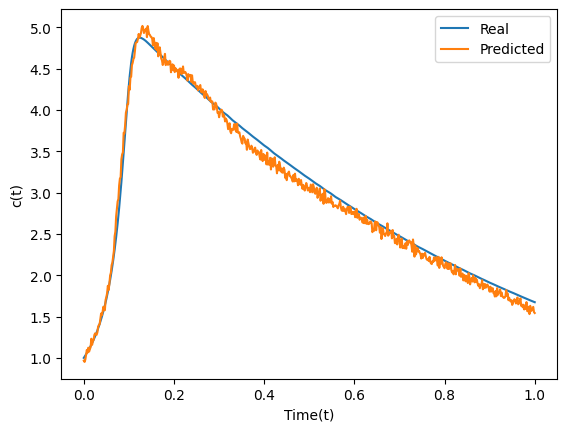

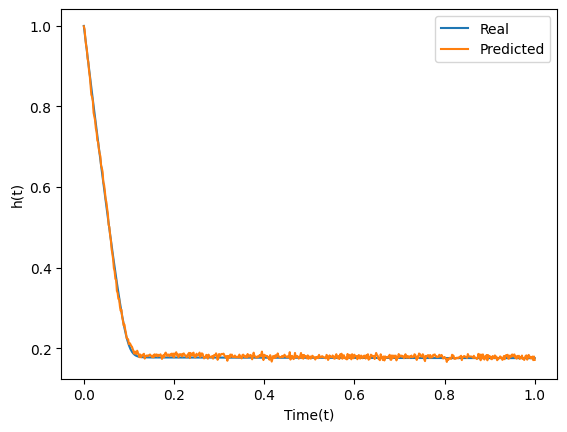

In [66]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

**Further inspection**

In [67]:
pred_c = model_c.predict(data_i_test)
error_c = np.sum((data_c_test - pred_c)**2, axis=1)/601
max_error_c = np.max(error_c)
print(max_error_c, np.mean(error_c))
max_error_index_c = np.argmax(error_c)
print("Index of max_error:", max_error_index_c)

42.8115 0.056059003
Index of max_error: 5596


In [68]:
pred_h = model_h.predict(data_i_test)
error_h = np.sum((data_h_test - pred_h)**2, axis=1)/601
max_error_h = np.max(error_h)
print(max_error_h, np.mean(error_h))
max_error_index_h = np.argmax(error_h)
print("Index of max_error:", max_error_index_h)

0.4859034 0.002136191
Index of max_error: 11590


5596


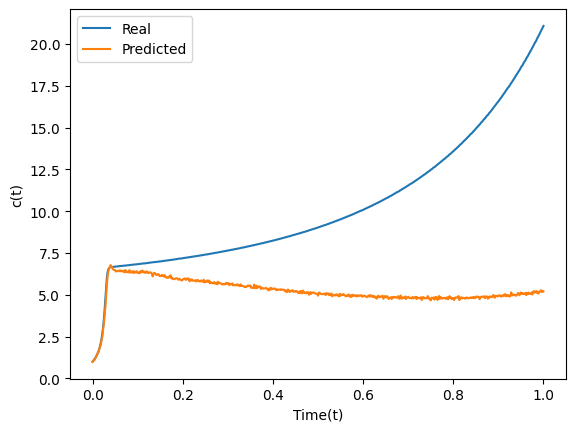

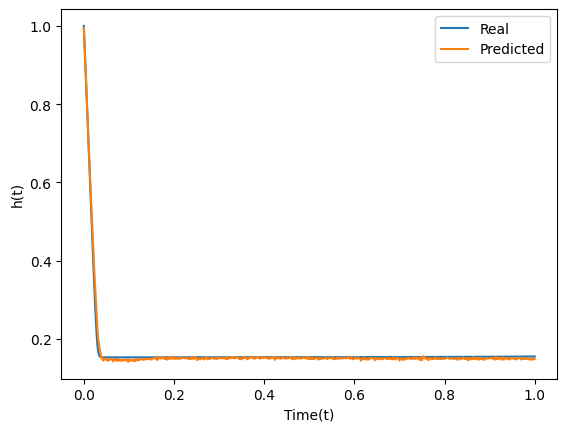

In [69]:
n = max_error_index_c
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

11590


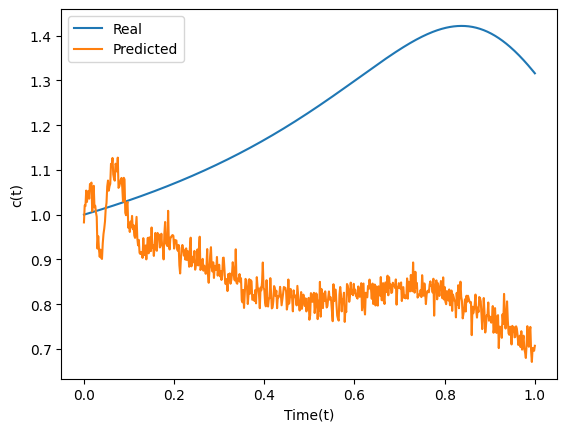

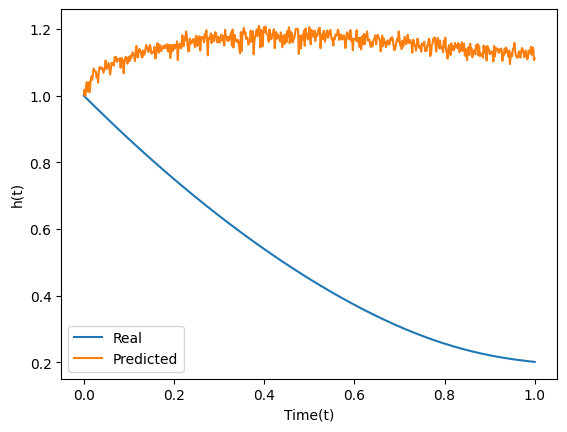

In [70]:
n = max_error_index_h
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

In [73]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2"
model_c.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2-1800.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2-1800.ckpt'

In [74]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2"
model_h.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2-1800.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2-1800.ckpt'